# Minimal VAE Implementation in PyTorch



In this notebook, we explore **Variational Autoencoders (VAEs)**, a powerful class of generative models used for data generation and reconstruction. Unlike standard Autoencoders that map input to a fixed vector, VAEs map input to a *probability distribution* in the latent space, making them excellent for generating new, diverse data.

## 1. Model Architecture
The VAE consists of two main parts:

*   **The Encoder (Inference Network):**
    *   **Goal:** Compresses the input image into a lower-dimensional latent representation.
    *   **Mechanism:** Instead of outputting a single vector, it outputs parameters of a probability distribution: the **Mean ($\mu$)** and **Log-Variance ($\log(\sigma^2)$)**.
    *   **Layers:** We use **Convolutional Layers** with stride to downsample the spatial dimensions, effectively capturing high-level features and relations within the data.
   *   *Structure:* Input (3x128x128) $\to$ 4 Conv Blocks (Conv+BatchNorm+LeakyReLU) with increasing channels (32, 64, 128, 256) $\to$ Flatten (256x8x8 = 16384) $\to$ Dropout (0.2) $\to$ Latent Vector (size 100).

*   **The Decoder (Generative Network):**
    *   **Goal:** Takes a sample $z$ from the latent distribution and reconstructs the original image.
    *   **Mechanism:** Uses **Transposed Convolutional Layers** (often called deconvolution) to upsample the data back to the original size.
    *   **Output Layer:** Uses a **Sigmoid** activation function to normalize pixel values between 0 and 1, matching the input data range.
    *   *Structure:* Latent Vector (100) $\to$ FC $\to$ Reshape (256x8x8) $\to$ Dropout (0.2) $\to$ 3 Transposed Conv Blocks (ConvT+BatchNorm+LeakyReLU) (128, 64, 32 channels) $\to$ Transposed Conv (3 channels) $\to$ Sigmoid $\to$ Output (3x128x128).

## 2. Key Concepts & Intuition

### The Latent Space & Reparameterization

**Why do we need a distribution?**
In a standard Autoencoder, the encoder maps an input to a single, fixed point in the latent space. This often leads to a discontinuous space where "gaps" exist between meaningful data points. If you sample from these gaps, you get garbage output.

A VAE solves this by mapping the input to a **probability distribution** (specifically, a multivariate Gaussian) rather than a single point. This means the encoder says: *"I'm not sure exactly where this image is, but it's somewhere in this region."*

*   **$\mu$ (Mean):** The center of this region. It represents the "best guess" for the image's location in latent space.
*   **$\log(\sigma^2)$ (Log Variance):** The size or "radius" of this region. It represents the uncertainty. A larger variance means the model is less sure, or that the image can be represented by a wider range of latent codes.

**The Problem: Backpropagation & Randomness**
To train the network, we need to calculate gradients (derivatives) of the loss with respect to the weights.
If we sample $z$ directly from the distribution $N(\mu, \sigma^2)$, the operation is **stochastic** (random). You cannot calculate the gradient of a random process. The chain rule of calculus breaks because there is no deterministic path from the output back to the encoder weights.

**The Solution: The Reparameterization Trick**
We use a clever mathematical trick to bypass the random node. Instead of sampling $z$ directly, we construct it:

$$z = \mu + \sigma \cdot \epsilon$$

Where:
*   **$\mu$ and $\sigma$** are deterministic outputs of the encoder (we can calculate gradients for them).
*   **$\epsilon \sim \mathcal{N}(0, 1)$** is random noise sampled from a standard normal distribution.

**Intuition:** Think of it like an archer.
*   **$\mu$** is where the archer aims (deterministic).
*   **$\sigma$** is how shaky the archer's hand is (deterministic property of the archer).
*   **$\epsilon$** is the wind or random chance (stochastic).

By writing it this way, the randomness ($\epsilon$) is an external input, not a node in the computational graph we need to differentiate through. We can now backpropagate through $\mu$ and $\sigma$ to update the encoder!

### The Loss Function (ELBO)
The objective function minimizes two conflicting terms:
1.  **Reconstruction Loss (MSE):** Measures the pixel-wise difference between the generated image and the original input. It encourages the model to reproduce the input accurately.
2.  **KL Divergence (Kullback-Leibler):** A regularization term that measures the divergence between the learned latent distribution and a Standard Normal Distribution ($\mathcal{N}(0, 1)$).
    *   This forces the latent space to be continuous and smooth, ensuring that points close to each other in latent space decode to similar images.
    *   *Note:* In our implementation, we use a scaling factor (`B`) to balance the magnitude of the reconstruction loss against the KL divergence.

### Inference (Generation)
To generate new data (inference), we simply sample a random vector $z$ from a Standard Normal Distribution ($\mathcal{N}(0, 1)$) and pass it through the **Decoder**. Since the model was regularized to map this distribution to valid images, it generates novel, realistic data similar to the training set.

In [16]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.decomposition import PCA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


### Configure parameters and path 

In [26]:
#convert path to absolut path
DATA_PATH = os.path.expanduser('~/deepLearning/AnimusVision/fox_in_snow_real')
INPUT_DIM = (128,128)
BATCH_SIZE = 8
Z_DIM = 100
LR = 1e-4 #0.0001
EPOCHS = 20


### Crate Class Costum Dataset

In [27]:
class ImageDataset(Dataset):
    def __init__(self, root_dir, transform = None):
        self.root_dir = root_dir
        self.transform = transform
        # '**' get through any subdirectory to the images
        self.image_paths = glob.glob(os.path.join(root_dir, '**', '*.jpg'))

        if len(self.image_paths) == 0:
            # to search even at the sublebel directory not only the top level 
            self.image_paths = glob.glob(os.path.join(root_dir, '**', '*.jpg'), recursive=True)
        
        print(f"Found {len(self.image_paths)} images in {root_dir}")

    def __len__(self):
        return len(self.image_paths)
        
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

### Apply transformation for Data Augmentation

In [28]:
transform = transforms.Compose([
    transforms.Resize(INPUT_DIM),
    transforms.RandomHorizontalFlip(), # 50% chance to flip image
    transforms.RandomRotation(10), # Rotation with 10 degrees to a random side
    #no rotation, shift image to horizontally and verticall randomly, 
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), shear=0.05, scale=(0.9, 1.1)),
    transforms.ToTensor(),
])

dataset = ImageDataset(DATA_PATH, transform=transform)
# shuffle to randomize the order of data at the begginning of each epoch so each batch will get diffrent data from the the previous epoch
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

Found 100 images in /info/etu/m2/s2405959/deepLearning/AnimusVision/fox_in_snow_real


### Implement The variational auto-encoder. 

In [29]:
class VAE(nn.Module):
    def __init__(self, z_dim=100):
        # lets a child class call methods from its parent class.
        super(VAE, self).__init__()
        
        #Encoder
        # input_channel=3, ouput_channel=32, moving with 2 pix each time, add 1 dim of 0 aroud image 
        self.enc_conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.enc_conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.enc_conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.enc_conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.flatten_dim = 256 * 8 * 8
        
        # Dropout to prevent overfitting on small dataset
        self.dropout = nn.Dropout(0.2)

        self.fc_mu = nn.Linear(self.flatten_dim, z_dim)
        # To calculate the log variance of the distribution, which will determine how spread out the latent variables are
        self.fc_logvar = nn.Linear(self.flatten_dim, z_dim)

        # Decoder 
        self.dec_fc = nn.Linear(z_dim, self.flatten_dim)

        self.dec_conv1 = nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dbn1 = nn.BatchNorm2d(128)

        self.dec_conv2 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dbn2 = nn.BatchNorm2d(64)
        
        self.dec_conv3 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dbn3 = nn.BatchNorm2d(32)
        
        self.dec_conv4 = nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1)

    def encode(self, x):
        x = F.leaky_relu(self.bn1(self.enc_conv1(x)))
        x = F.leaky_relu(self.bn2(self.enc_conv2(x)))
        x = F.leaky_relu(self.bn3(self.enc_conv3(x)))
        x = F.leaky_relu(self.bn4(self.enc_conv4(x)))
        
        x = x.view(x.size(0), -1)
        x = self.dropout(x) # Apply dropout before latent projection
        
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        x = self.dec_fc(z)
        x = x.view(x.size(0), 256, 8, 8)
        x = self.dropout(x)
        
        x = F.leaky_relu(self.dbn1(self.dec_conv1(x)))
        x = F.leaky_relu(self.dbn2(self.dec_conv2(x)))
        x = F.leaky_relu(self.dbn3(self.dec_conv3(x)))
        x = torch.sigmoid(self.dec_conv4(x)) 
        return x
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar 

model = VAE(z_dim=Z_DIM).to(device)
# AdamW handles weight decay better than Adam, helping with regularization
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
print(model)

VAE(
  (enc_conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc_mu): Linear(in_features=16384, out_features=100, bias=True)
  (fc_logvar): Linear(in_features=16384, out_features=100, bias=True)
  (dec_fc): Linear(in_features=100, out_features=16384, bias=True)
  (dec_conv1): ConvTranspose2d(256, 128, kernel_size=(3, 3), stri

### define the loss fonction 


In [30]:
def Criterien(recon_x, x, mu, logvar):
    B = 15000
    # MSE Loss
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    
    # KL Divergence
    # It measures how much the learned latent distribution deviates from a standard normal distribution.
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    kl_loss /= x.size(0)
    
    return B * recon_loss + kl_loss


### defien training fonction


In [31]:
def train(model, dataloader, optimizer, epochs):
    model.train()
    all_losses = []

    for epoch in range(epochs):
        total_loss = 0

        for batch_idx, data in enumerate(dataloader):
            data = data.to(device)
            optimizer.zero_grad()
            # forward
            recon_batch, mu, logvar = model(data)

            #loss
            loss = Criterien(recon_batch, data , mu, logvar)
            loss.backward()
            optimizer.step()
            total_loss+= loss
        
        epoch_loss = total_loss / len(dataloader)

        all_losses.append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

    # save model
    torch.save(model.state_dict(), "vae_best.pth")

    return all_losses




In [32]:
model = VAE(z_dim=Z_DIM).to(device)
# AdamW handles weight decay better than Adam, helping with regularization
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)


# Train the model
losses = train(model, dataloader, optimizer, EPOCHS)

Epoch 1/20, Loss: 2248.9739
Epoch 2/20, Loss: 2080.4819
Epoch 2/20, Loss: 2080.4819
Epoch 3/20, Loss: 1994.0228
Epoch 3/20, Loss: 1994.0228
Epoch 4/20, Loss: 1885.4294
Epoch 4/20, Loss: 1885.4294
Epoch 5/20, Loss: 1785.3044
Epoch 5/20, Loss: 1785.3044
Epoch 6/20, Loss: 1710.0354
Epoch 6/20, Loss: 1710.0354
Epoch 7/20, Loss: 1650.8735
Epoch 7/20, Loss: 1650.8735
Epoch 8/20, Loss: 1571.3733
Epoch 8/20, Loss: 1571.3733
Epoch 9/20, Loss: 1511.4236
Epoch 9/20, Loss: 1511.4236
Epoch 10/20, Loss: 1488.4991
Epoch 10/20, Loss: 1488.4991
Epoch 11/20, Loss: 1387.8733
Epoch 11/20, Loss: 1387.8733
Epoch 12/20, Loss: 1351.1061
Epoch 12/20, Loss: 1351.1061
Epoch 13/20, Loss: 1332.1086
Epoch 13/20, Loss: 1332.1086
Epoch 14/20, Loss: 1306.1311
Epoch 14/20, Loss: 1306.1311
Epoch 15/20, Loss: 1258.7689
Epoch 15/20, Loss: 1258.7689
Epoch 16/20, Loss: 1216.1448
Epoch 16/20, Loss: 1216.1448
Epoch 17/20, Loss: 1191.9647
Epoch 17/20, Loss: 1191.9647
Epoch 18/20, Loss: 1194.5830
Epoch 18/20, Loss: 1194.5830
Ep

### plot images fonction 

**Note** : To obtain very good results, we have to run the code for very long hours, like a few thousand epochs  

Display generated images with their matching ones from the dataset to see the capability of the module of generating.


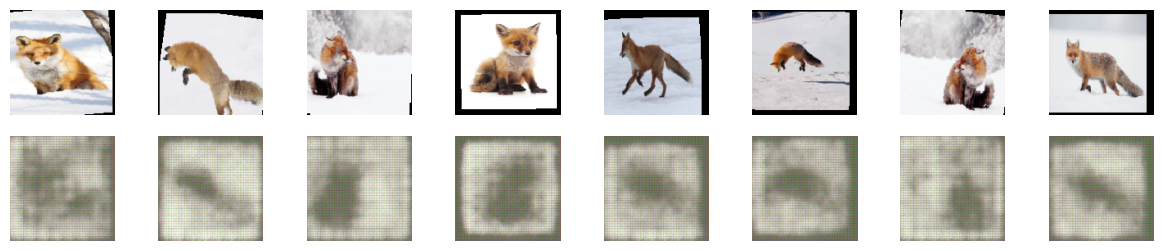

Display randomly generated images:


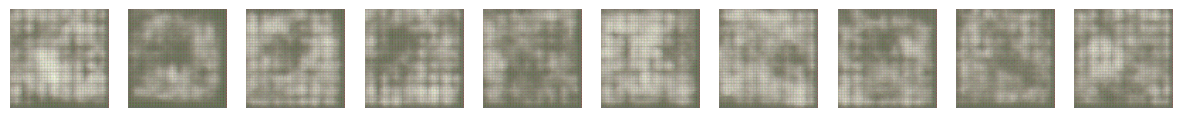

In [37]:
model.eval()
def show_images(model, n_to_show=10):
    print('Display generated images with their matching ones from the dataset to see the capability of the module of generating.')
    with torch.no_grad():
        data = next(iter(dataloader))
        n_to_show = min(n_to_show, data.size(0))
        data = data[:n_to_show].to(device)
        recon, _, _ = model(data)
        
        fig, axes = plt.subplots(2, n_to_show, figsize=(15, 3))
        for i in range(n_to_show):
            img = data[i].cpu().permute(1, 2, 0).numpy()
            axes[0, i].imshow(img)
            axes[0, i].axis('off')
            
            recon_img = recon[i].cpu().permute(1, 2, 0).numpy()
            axes[1, i].imshow(recon_img)
            axes[1, i].axis('off')
        plt.show()

def generate_images(model, n_to_show=10):
    print("Display randomly generated images:")
    with torch.no_grad():
        z = torch.randn(n_to_show, Z_DIM).to(device)
        generated = model.decode(z)
        
        fig, axes = plt.subplots(1, n_to_show, figsize=(15, 3))
        for i in range(n_to_show):
            img = generated[i].cpu().permute(1, 2, 0).numpy()
            axes[i].imshow(img)
            axes[i].axis('off')
        plt.show()

show_images(model)
generate_images(model)

### Visualizing the Latent Space with Real Images

Here, we project the 100-dimensional latent vectors ($\mu$) down to 2 dimensions using **PCA** and plot the actual input images at their encoded locations.

**Interpreting the Plot:**
This visualization reveals how the VAE organizes data with **semantic clustering**, where images sharing similar features (like pose, color, or background) are grouped together. The spatial arrangement shows the model's internal "map" of the data: nearby images are considered similar by the network, while distant ones are distinct. This confirms that the model has learned a meaningful, continuous representation of the dataset.

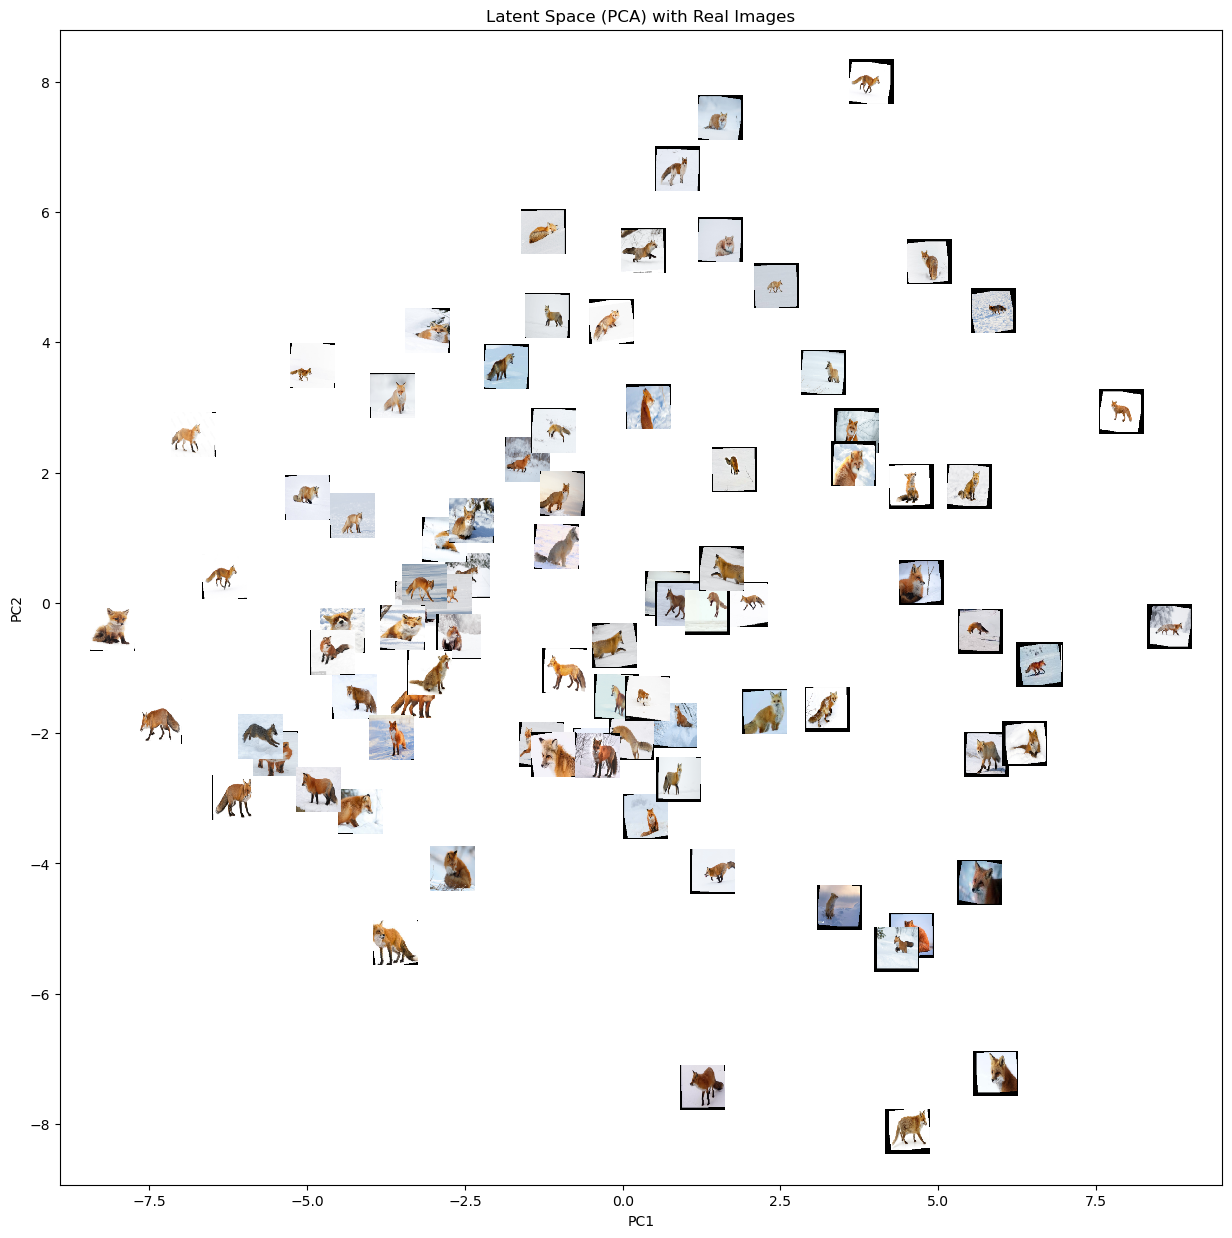

In [36]:

def plot_latent_space(model, dataloader):
    model.eval()
    all_z = []
    all_images = []
    with torch.no_grad():
        # Collect a few batches
        for i, data in enumerate(dataloader):
            if i > 10: break
            data = data.to(device)
            mu, _ = model.encode(data)
            all_z.append(mu.cpu().numpy())
            all_images.append(data.cpu())
    
    all_z = np.concatenate(all_z, axis=0)
    all_images = torch.cat(all_images, dim=0)
    
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(all_z)
    
    fig, ax = plt.subplots(figsize=(15, 15))
    # Plot invisible scatter points to set the axis limits automatically
    ax.scatter(z_2d[:, 0], z_2d[:, 1], alpha=0)
    
    for i in range(len(z_2d)):
        # Convert tensor (C, H, W) to numpy (H, W, C) for plotting
        img = all_images[i].permute(1, 2, 0).numpy()
        # Ensure values are valid for display
        img = np.clip(img, 0, 1)
        
        # Create an image box
        im = OffsetImage(img, zoom=0.25) # Adjust zoom to change image size
        ab = AnnotationBbox(im, (z_2d[i, 0], z_2d[i, 1]), xycoords='data', frameon=False)
        ax.add_artist(ab)
    
    plt.title("Latent Space (PCA) with Real Images")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

plot_latent_space(model, dataloader)